<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/marco-canas/didactica_ciencia_datos/blob/main/referentes/geron/part_1/c_4/c_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
</table>

## [Lista de reproducción en YouTube para acompañar la lectura experimental de este capítulo](https://www.youtube.com/watch?v=FRqaBqy3prU&list=PLbk60veMSVKv7dAGRFIBwUf34TFDL0FdW)

# Capítulo 4
## ¿Qué significa entrenar un modelo? 
Aurelien Gerón

Hasta ahora, hemos tratado los modelos de Machine Learning y sus algoritmos de entrenamiento en su mayoría como cajas negras.

Si realizó algunos de los ejercicios de los capítulos anteriores, es posible que se haya sorprendido de todo lo que puede hacer sin saber nada sobre lo que hay debajo del capó:  

* optimizó un sistema de regresión,   
* mejoró un clasificador de imágenes de dígitos e incluso 
* construyó un clasificador de spam desde cero,   

todo esto sin saber cómo funcionan realmente.

De hecho, en muchas situaciones no es necesario conocer los detalles de implementación.

Sin embargo, tener una buena comprensión de cómo funcionan las cosas puede ayudarlo a:

* encontrar rápidamente el modelo apropiado, 
* el algoritmo de entrenamiento adecuado para usar y 
* un buen conjunto de hiperparámetros para su tarea. 

Comprender qué hay debajo del capó también lo ayudará a 
* depurar problemas y 
* realizar análisis de errores de manera más eficiente.

Por último, la mayoría de los temas discutidos en este capítulo serán esenciales para comprender, construir y entrenar redes neuronales (discutidos en la Parte II de este libro).

Habrá bastantes ecuaciones matemáticas en este capítulo, usando nociones básicas de álgebra lineal y cálculo.

Para comprender estas ecuaciones, necesitarás saber:  

* qué son los vectores y las matrices; 
* cómo transponerlos, multiplicarlos e invertirlos; y 
* qué son las derivadas parciales.

Si no está familiarizado con estos conceptos, consulte los tutoriales introductorios de cálculo y álgebra lineal disponibles como cuadernos de Jupyter en el material complementario en línea.  

Para aquellos que son realmente alérgicos a las matemáticas, aún deben leer este capítulo y simplemente omitir las ecuaciones; 
* con suerte, el texto será suficiente para ayudarlo a comprender la mayoría de los conceptos.

## Linear Regression  

En el Capítulo 1 analizamos un modelo de regresión simple de calidad de vida:

* un modelo lineal hace una predicción simplemente calculando una **suma ponderada** de los atributos de entrada, 
* más una constante llamada **término de sesgo** (también llamado **término de intersección**)

Equation 4-1. Modelo predictivo de regresión lineal (Linear Regression model prediction)  


$$ \hat{y} = \theta_{0} + \theta_{1}x_{1} + \theta_{2}x_{2} + \cdots + \theta_{n}x_{n} $$



$$ \hat{y} = \theta_{0} + \theta_{1}x_{1} + \theta_{2}x_{2} + \cdots + \theta_{n}x_{n} $$

$$ \hat{y} = \mathbf{\theta} \cdot \mathbf{x}_{b}$$  



En esta ecuación:

$\hat{y}$ es el valor predicho.

$n$ es el número de características o atributos.

$x_{i}$ es el valor de la $i$ - ésimo atributo.

* $\theta_{j}$ es el $j$ - ésimo parámetro del modelo 
* (incluido el término de sesgo $\theta_{0}$ y los pesos de los atributos $\theta_{1},\theta_{2},\ldots, \theta_{n}$).

Esto se puede escribir de manera mucho más concisa usando una forma vectorizada, como se muestra en la siguiente ecuación.

Ecuación 4-2. Predicción del modelo de regresión lineal (forma vectorizada)   


$$ \hat{y} = h_{\mathbf{\theta}}(\mathbf{x}_{b}) = \mathbf{\theta} \cdot \mathbf{x}_{b} $$

En esta ecuación:

* $\mathbf{\theta}$ es el vector de parámetros del modelo, que contiene el término de sesgo $\theta_{0}$ y el de los pesos de los atributos $\theta_{1}$ a $\theta_{n}$.

* $\mathbf{x}_{b}$ es el **vector de atributos** o de instancias, que contiene $x_{0}$ a $x_{n}$, con $x_{0}$ siempre igual a $1$.

* $\mathbf{\theta} \cdot \mathbf{x}_{b}$ es el producto escalar de los vectores $\mathbf{\theta}$ y $\mathbf{x}_{b}$, que por supuesto es igual a $\theta_{0}x_{0} + \theta_{1}x_{1} + \theta_{2}x_{2} + \cdots + \theta_{n}x_{n}.$

* $h_{\mathbf{\theta}}$ es la función hipótesis asociada a los parámetros $\mathbf{\theta}$ del modelo.

## NOTA

Si $\mathbf{\theta}$ y $\mathbf{x}_{b}$ son vectores de columna, entonces la predicción es 

$$ \hat{y} = \mathbf{\theta}^{T}\mathbf{x}_{b}, $$

donde $\mathbf{\theta}^{T}$ es la transposición de $\mathbf{\theta}$ (un vector de fila en lugar de un vector de columna) y   
$\mathbf{\theta}^{T}\mathbf{x}_{b}$ es el producto matricial las matrices $\theta^{T}$ y $\mathbf{x}_{b}$.

* este es el modelo de regresión lineal,   
* pero ¿cómo lo entrenamos?   

Recuerde que **entrenar un modelo** significa **establecer sus parámetros** para que el modelo se ajuste mejor al **conjunto de entrenamiento**.

Para este propósito, primero necesitamos una medida de qué tan bien (o mal) el modelo se ajusta a los datos de entrenamiento.

La medida de rendimiento más común de un modelo de regresión es el la raíz del error cuadrático medio (RMSE).

$$ RMSE(\theta) = \sqrt{\frac{1}{m}\sum_{j = 0}^{n} (\theta^{T} x^{j} - y^{j})^{2}} $$

Por lo tanto, para entrenar un modelo de regresión lineal, necesitamos encontrar el valor de $\theta$ que minimice el RMSE.

* En la práctica, es más sencillo minimizar el error cuadrático medio (MSE) que el RMSE, 
* y conduce al mismo resultado (pues el valor que minimiza a la función, minimiza su raíz cuadrada). 

Se calcula el MSE de una hipótesis de regresión lineal $h$ en un conjunto de entrenamiento `X_train` usando la ecuación:  

$$ RMSE(\theta) = \sqrt{\frac{1}{m}\sum_{j = 0}^{n} (\theta^{T} x^{j} - y^{j})^{2}} $$


o la ecuación:

$$ MSE(X,h_{\theta}) = \frac{1}{m} \sum_{i = 1}^{n} (\mathbf{\theta}^{T}\mathbf{x}^{i} - y^{i} )^{2} $$

La única diferencia es que escribimos $h_{\mathbf{\theta}}$ en lugar de solo $h$ para dejar en claro que el modelo está parametrizado por el vector $\mathbf{\theta}$.

Para simplificar las notaciones, simplemente escribiremos $MSE(\mathbf{\theta})$ en lugar de $MSE(\mathbf{X}, h_{\mathbf{\theta}})$.

## La ecuación normal

Para encontrar el valor de $\mathbf{\theta}$ que minimiza la función de costo, existe una solución de forma cerrada, 
* en otras palabras, una ecuación matemática que da el resultado directamente.

Esto se llama **ecuación normal**

$$ \hat{\mathbf{\theta}} = (\mathbf{X}^{T}\mathbf{X})^{-1} \mathbf{X}^{T}\mathbf{y} $$

En esta ecuación:

* $\hat{\mathbf{\theta}}$ es el valor de $\mathbf{\theta}$ que minimiza la función de costo.

* $\mathbf{y}$ es el vector de valores objetivo que contiene $y^{(1)}$ a $y^{(m)}$.

# Generemos algunos datos de apariencia lineal para probar esta ecuación:

In [1]:
import numpy as np
import matplotlib.pyplot as plt  


In [2]:
# Fijamos un estado aleatorio para reproducibilidad
np.random.seed(48)
X = 2 * np.random.rand(100, 1) 
# Crea una matriz de orden 100 x 1 con valores aleatorios en el intervalo [0,2) 
# que distribuyen uniforme
y = 4 + 3 * X + np.random.randn(100, 1) # crea un vector de etiquetas

In [3]:
X[:5]

array([[0.03498054],
       [1.78314653],
       [0.56972233],
       [0.59795275],
       [1.58406852]])

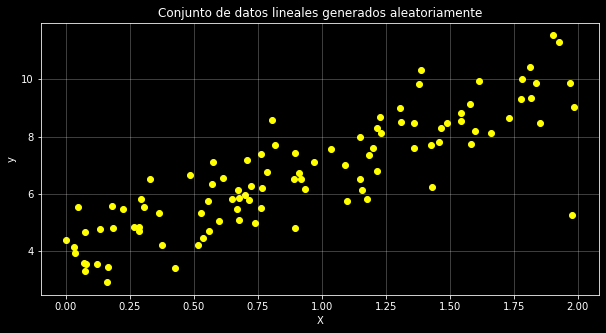

In [6]:
plt.figure(figsize=(10,5)) 
#plt.style.use('dark_background') 
plt.scatter(X,y, color = 'yellow')    
plt.xlabel('X')
plt.ylabel('y')
plt.title('Conjunto de datos lineales generados aleatoriamente')


plt.grid(alpha = 0.3) 
plt.savefig('dataset_lineal_aleatorio.jpg')

plt.show() 

Ahora calculemos $\hat{\mathbf{\theta}}$ usando la Ecuación Normal. 

Usaremos la función ``inv()`` del módulo de álgebra lineal de NumPy `` (np.linalg) `` para calcular la inversa de una matriz, y el método ``.dot()`` para la multiplicación de matrices:

In [7]:
import numpy as np 
# np.c_ concatena matrices 
X_b = np.c_[np.ones((100, 1)), X] # add x0 = 1 to each instance
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
theta_best 

array([[4.0117793 ],
       [2.92444191]])

La función que usamos para generar los datos es $y = 4 + 3x + \text{Ruido Gausiano}$.

Veamos qué encontró la ecuación:

In [8]:
theta_best

array([[4.0117793 ],
       [2.92444191]])

Habríamos esperado $\theta_{0} = 4$ y $\theta_{1}=3$ en lugar de $\theta_{0} = 4.01$ y $\theta_{1} = 2.924$.

Lo suficientemente cerca, pero el ruido hizo imposible recuperar los parámetros exactos de la función original.

Ahora podemos hacer predicciones usando $\hat{\mathbf{\theta}}$:

In [9]:
X_new = np.array([[0], [2]])
X_new_b = np.c_[np.ones((2, 1)), X_new] # add x0 = 1 to each instance
y_predict = X_new_b.dot(theta_best)
y_predict

array([[4.0117793 ],
       [9.86066312]])

Grafiquemos las predicciones de este modelo (Figura 4-2):

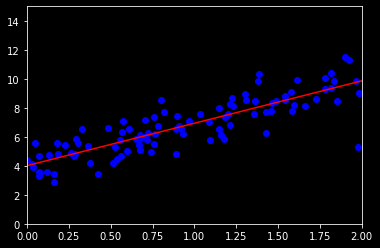

In [6]:
plt.plot(X_new, y_predict, "r-")
plt.scatter(X, y, color = 'blue') 
plt.axis([0, 2, 0, 15])
plt.savefig('que_significa_entrenar_un_modelo.jpg')
plt.show()

# Realizar una regresión lineal con Scikit-Learn es simple:

In [10]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X, y)
lin_reg.intercept_, lin_reg.coef_

(array([4.0117793]), array([[2.92444191]]))

In [ ]:
X_new = np.array([[0], [2]])
lin_reg.predict(X_new)

La clase ``LinearRegression`` se basa en la función ``scipy.linalg.lstsq()`` (el nombre significa "mínimos cuadrados"), a la que puede llamar directamente:

In [11]:
theta_best_svd, residuals, rank, s = np.linalg.lstsq(X_b, y, rcond=1e-6)
theta_best_svd

array([[4.0117793 ],
       [2.92444191]])

Esta función calcula $\hat{\theta} = X^{+}y$ donde $X^{+}$ es la pseudoinversa de $X$ (específicamente, la inversa de Moore-Penrose).

Puede usar `np.linalg.pinv()` para calcular la pseudoinversa directamente:

In [ ]:
np.linalg.pinv(X_b).dot(y)

La pseudoinversa en sí misma se calcula usando una técnica de factorización de matrices estándar llamada *Descomposición de valores singulares* (SVD) que puede descomponer la matriz del conjunto de entrenamiento $\mathbf{X}$ en la multiplicación de tres matrices $U\Sigma V^{T}$ (ver ``numpy.linalg.svd()``).

La pseudoinversa se calcula como $\mathbf{X}^{+} = \mathbf{V\Sigma}^{+}\mathbf{U}^{T}$.   

Para calcular la matriz $\Sigma^{+}$, el algoritmo toma $\Sigma$ y establece en cero todos los valores menores que un pequeño valor de umbral, luego reemplaza todos los valores distintos de cero con su inversa y finalmente transpone el resultado matriz.

Este enfoque es más eficiente que calcular la Ecuación Normal, además maneja muy bien los casos extremos: de hecho, la Ecuación Normal puede no funcionar si la matriz $\mathbf{X}^{T}\mathbf{X}$ no es invertible (es decir, singular), como si $m < n$ o si algunas características son redundantes, pero la pseudoinversa siempre está definida.

## Computational Complexity

La ecuación normal calcula la inversa de $X^{T}X$, que es una matriz $(n + 1) \times (n + 1)$ (donde $n$ es el número de características).

La complejidad computacional de invertir una matriz de este tipo suele ser de $O(n^{2.4})$ a $O(n^{3})$, según la implementación. 

En otras palabras, si duplica la cantidad de características, multiplica el tiempo de cálculo por aproximadamente $2^{2.4} = 5.3$ a $2^{3} = 8$.

El enfoque SVD utilizado por la clase LinearRegression de Scikit-Learn es aproximadamente $O(n^{2})$. 

Si duplica la cantidad de características, multiplica el tiempo de cálculo por aproximadamente 4.

## Advertencia 

Tanto la ecuación normal como el enfoque SVD se vuelven muy lentos cuando la cantidad de características aumenta (por ejemplo, 100,000).

En el lado positivo, ambos son lineales con respecto a la cantidad de instancias en el conjunto de entrenamiento (son $O(m)$), por lo que manejan grandes conjuntos de entrenamiento de manera eficiente, siempre que quepan en la memoria.

Además, una vez que haya entrenado su modelo de regresión lineal (usando la ecuación normal o cualquier otro algoritmo), las predicciones son muy rápidas: la complejidad computacional es lineal con respecto a la cantidad de instancias en las que desea hacer predicciones y la cantidad de atributos.

En otras palabras, hacer predicciones sobre el doble de instancias (o el doble de funciones) llevará aproximadamente el doble de tiempo.

Ahora veremos una forma muy diferente de entrenar un modelo de regresión lineal, que se adapta mejor a los casos en los que hay una gran cantidad de funciones o demasiadas instancias de entrenamiento para caber en la memoria.

## Gradient Descent  

Gradient Descent es un algoritmo de optimización genérico capaz de encontrar soluciones óptimas a una amplia gama de problemas.

La idea general de Gradient Descent es ajustar los parámetros iterativamente para minimizar una función de costo.

Suponga que está perdido en las montañas en una densa niebla, y solo puede sentir la pendiente del suelo debajo de sus pies.

Una buena estrategia para llegar rápidamente al fondo del valle es descender en dirección a la pendiente más pronunciada.

Esto es exactamente lo que hace Gradient Descent: mide el gradiente local de la función de error con respecto al vector de parámetros $\theta$, y va en la dirección del gradiente descendente. 

Una vez que el gradiente es cero, ¡ha alcanzado un mínimo!

Concretamente, comienza llenando θ con valores aleatorios (esto se llama inicialización aleatoria).

Luego lo mejora gradualmente, dando un pequeño paso a la vez, cada paso intentando disminuir la función de costo (por ejemplo, el MSE), hasta que el algoritmo converge a un mínimo (vea la Figura 4-3).

<img src='figure_4_3.jpg'>

Un parámetro importante en Gradient Descent es el tamaño de los pasos, determinado por el hiperparámetro de tasa de aprendizaje. 

Si la tasa de aprendizaje es demasiado pequeña, el algoritmo tendrá que pasar por muchas iteraciones para converger, lo que llevará mucho tiempo (consulte la Figura 4-4).

<img src='figure_4_4.jpg'>

Por otro lado, si la tasa de aprendizaje es demasiado alta, es posible que saltes al otro lado del valle y termines en el otro lado, posiblemente incluso más alto de lo que estabas antes.

Esto podría hacer que el algoritmo diverja, con valores cada vez mayores, y no pueda encontrar una buena solución (consulte la Figura 4-5).

<img src='figure_4_5.jpg'>

Por último, no todas las funciones de costos se ven como buenos cuencos normales. 

Puede haber agujeros, crestas, mesetas y todo tipo de terrenos irregulares, haciendo dificil la convergencia al mínimo global. 

La figura 4-6 muestra los dos desafíos principales del Gradiente descendente.

Si la inicialización aleatoria inicia el algoritmo de la izquierda, entonces
convergen a un mínimo local, que no es tan bueno como el mínimo global. Si se
comienza a la derecha, luego tomará mucho tiempo cruzar la meseta. Y si
si se detiene demasiado pronto, nunca alcanzará el mínimo global.

<img src='figure_4_6.jpg'> 

Afortunadamente, la función de costo de MSE para un modelo de regresión lineal resulta ser una función convexa, lo que significa que si selecciona dos puntos en la curva, el segmento de línea que los une nunca cruza la curva.

This implies that there are no local minima, just one global minimum. 

It is also a continuous function with a slope that never changes abruptly.  

Estos dos hechos tienen una gran consecuencia:
* Se garantiza que Gradient Descent se acerque arbitrariamente al mínimo global (si espera lo suficiente y si la tasa de aprendizaje no es demasiado alta).

De hecho, la función de coste tiene forma de cuenco, pero puede ser un cuenco alargado si las características tienen escalas muy diferentes.

La figura 4-7 muestra el descenso de gradiente en un conjunto de entrenamiento donde las funciones 1 y 2 tienen la misma escala (a la izquierda) y en un conjunto de entrenamiento donde la función 1 tiene valores mucho más pequeños que la función 2 (a la derecha).

<img src='figure_4_7.jpg'> 

Como puedes ver, a la izquierda el algoritmo de Descenso de Gradiente va directo hacia el mínimo, alcanzándolo rápidamente, mientras que a la derecha primero va en una dirección casi ortogonal a la dirección del mínimo global, y termina con una marcha larga. por un valle casi plano.

Eventualmente alcanzará el mínimo, pero tomará mucho tiempo.

## Advertencia

Al usar Gradient Descent, debe asegurarse de que todas las funciones tengan una escala similar (p. ej., usando la clase StandardScaler de Scikit-Learn) o, de lo contrario, tardará mucho más en converger.  

Este diagrama también ilustra el hecho de que entrenar un modelo significa buscar una combinación de parámetros del modelo que minimice una función de costo (sobre el conjunto de entrenamiento).

Es una búsqueda en el espacio de parámetros del modelo: cuantos más parámetros tiene un modelo, más dimensiones tiene este espacio y más difícil es la búsqueda: buscar una aguja en un pajar de 300 dimensiones es mucho más complicado que en 3 dimensiones.

Afortunadamente, dado que la función de costo es convexa en el caso de la regresión lineal, la aguja simplemente está en el fondo del recipiente.

## Gradiente descendente incremental 

Para implementar Gradient Descent, debe calcular el gradiente de la función de costo con respecto a cada parámetro del modelo $\theta_{j}$.

En otras palabras, debe calcular cuánto cambiará la función de costo si cambia $\theta_{j}$ solo un poco.

A esto se le llama derivada parcial. 

Es como preguntar "¿Cuál es la pendiente de la montaña bajo mis pies si miro hacia el este?" y luego hacer la misma pregunta mirando al norte (y así sucesivamente para todas las demás dimensiones, si puedes imaginar un universo con más de tres dimensiones).

La ecuación 4-5 calcula la derivada parcial de la función de costo con respecto al parámetro $\theta_{j}$, anotó $\frac{\partial}{\partial \theta_{j}} MSE(\mathbf{\theta})$.

Ecuación 4-5. Derivadas parciales de la función de costo  

$$ \frac{\partial}{\partial \theta_{j}} MSE(\theta) = \frac{2}{m} \sum_{i = 1}^{m} (\theta^{T}x^{(i)} - y^{(i)})x_{j}^{(i)}     $$


En lugar de calcular estas derivadas parciales individualmente, puede usar la Ecuación 4-6 para calcularlas todas de una sola vez.

El vector gradiente, anotado $\nabla MSE(\theta)$, contiene todas las derivadas parciales de la función de costo (una para cada parámetro del modelo).

Equation 4-6. Gradient vector of the cost function  

$$ \nabla_{theta}MSE(\theta) = \begin{pmatrix} \frac{\partial}{\partial \theta_{0}}MSE(\theta) \\ \frac{\partial}{\partial \theta_{1}}MSE(\theta) \\ \vdots \\ \frac{\partial}{\partial \theta_{n}}MSE(\theta)   \end{pmatrix} = \frac{2}{m} X^{T}(X\theta - y) $$


## Advertencia

Tenga en cuenta que esta fórmula implica cálculos sobre el conjunto de entrenamiento completo `X`, en cada paso de descenso de gradiente.

Es por eso que el algoritmo se llama Batch Gradient Descent: utiliza el lote completo de datos de entrenamiento en cada paso (en realidad, Full Gradient Descent probablemente sería un mejor nombre).

Como resultado, es terriblemente lento en conjuntos de entrenamiento muy grandes (pero pronto veremos algoritmos de descenso de gradiente mucho más rápidos). 

Sin embargo, Gradient Descent se escala bien con la cantidad de características; Entrenar un modelo de regresión lineal cuando hay cientos de miles de entidades es mucho más rápido usando el descenso de gradiente que usando la ecuación normal o la descomposición SVD.

Una vez que tenga el vector de gradiente, que apunta cuesta arriba, simplemente vaya en la dirección opuesta para ir cuesta abajo.

Esto significa restar $\nabla MSE(\theta)$ de $\theta$.

Aquí es donde entra en juego la tasa de aprendizaje $\eta$: multiplica el vector de gradiente por $\eta$ para determinar el tamaño del paso cuesta abajo.

Equation 4-7. Gradient Descent step

$$ \theta^{\text{next step}} = \theta - \eta \nabla_{\theta} MSE(\theta) $$


Veamos una implementación rápida de este algoritmo:

In [ ]:
eta = 0.1 # learning rate
n_iterations = 1000
m = 100
theta = np.random.randn(2,1) # random initialization
for iteration in range(n_iterations):
    gradients = 2/m * X_b.T.dot(X_b.dot(theta) - y)
    theta = theta - eta * gradients

¡Eso no fue demasiado difícil! Veamos la theta resultante:


In [ ]:
theta

Hey, that’s exactly what the Normal Equation found! Gradient Descent worked perfectly. 

But what if you had used a different learning rate eta? 

Figure 4-8 shows the first 10 steps of Gradient Descent using three different learning rates (the dashed line represents the starting point).

figura 4-8
<img src = ''>

On the left, the learning rate is too low: the algorithm will eventually reach the solution, but it will take a long time. 

In the middle, the learning rate looks pretty good: in just a few iterations, it has already converged to the solution. 

On the right, the learning rate is too high: the algorithm diverges, jumping all over the place and actually getting further and further away from the solution at every step.

To find a good learning rate, you can use grid search (see Chapter 2). 

However, you may want to limit the number of iterations so that grid search can eliminate models that take too long to converge.

You may wonder how to set the number of iterations. 

If it is too low, you will still be far away from the optimal solution when the algorithm stops; but if it is too high, you will waste time while the model parameters do not change anymore. 

A simple solution is to set a very large number of iterations but to interrupt the algorithm when the gradient vector becomes tiny—that is, when its norm becomes smaller than a tiny number $\epsilon$ (called the tolerance)—because this happens when Gradient Descent has (almost) reached the minimum.

## CONVERGENCE RATE

When the cost function is convex and its slope does not change abruptly (as is the case for the MSE cost function), Batch Gradient Descent with a fixed learning rate will eventually converge to the optimal solution, but you may have to wait a while: it can take $O(1/\epsilon)$ iterations to reach the optimum within a range of $\epsilon$, depending on the shape of the cost function. 

If you divide the tolerance by 10 to have a more precise solution, then the algorithm may have to run about 10 times longer.

## Stochastic Gradient Descent

The main problem with Batch Gradient Descent is the fact that it uses the whole training set to compute the gradients at every step, which makes it very slow when the training set is large. 

At the opposite extreme, Stochastic Gradient Descent picks a random instance in the training set at every step and computes
the gradients based only on that single instance. Obviously, working on a single instance at a time makes the algorithm much faster because it has very little data to manipulate at every iteration. 

It also makes it possible to train on huge training sets, since only one instance needs to be in memory at each iteration
(Stochastic GD can be implemented as an out-of-core algorithm; see Chapter 1).

On the other hand, due to its stochastic (i.e., random) nature, this algorithm is much less regular than Batch Gradient Descent: instead of gently decreasing until it reaches the minimum, the cost function will bounce up and down, decreasing only on average. 

Over time it will end up very close to the minimum, but once it gets there it will continue to bounce around, never settling down (see Figure 4-9). 

So once the algorithm stops, the final parameter values are good, but not optimal.

<img src = 'https://github.com/marco-canas/didactica_ciencia_datos/blob/main/referentes/geron/part_1/c_4/figure_4_9.png?raw=true'> 

When the cost function is very irregular (as in Figure 4-6), this can actually help the algorithm jump out of local minima, so Stochastic Gradient Descent has a better chance of finding the global minimum than Batch Gradient Descent does.

Therefore, randomness is good to escape from local optima, but bad because it means that the algorithm can never settle at the minimum. 

One solution to this dilemma is to gradually reduce the learning rate. 

The steps start out large (which helps make quick progress and escape local minima), then get smaller and smaller, allowing the algorithm to settle at the global minimum. 

This process is akin to simulated annealing, an algorithm inspired from the process in metallurgy of annealing, where molten metal is slowly cooled down. 

The function that determines the learning rate at each iteration is called the learning schedule. 

If the learning rate is reduced too quickly, you may get stuck in a local minimum, or even end up frozen halfway to the minimum. 

If the learning rate is reduced too slowly, you may jump around the minimum for a long time and end up with a suboptimal solution if you halt training too early.

This code implements Stochastic Gradient Descent using a simple learning schedule:

In [ ]:
n_epochs = 50
t0, t1 = 5, 50 # learning schedule hyperparameters
def learning_schedule(t):
return t0 / (t + t1)
theta = np.random.randn(2,1) # random initialization
for epoch in range(n_epochs):
    for i in range(m):
        random_index = np.random.randint(m)
        xi = X_b[random_index:random_index+1]
        yi = y[random_index:random_index+1]
        gradients = 2 * xi.T.dot(xi.dot(theta) - yi)
        eta = learning_schedule(epoch * m + i)
        theta = theta - eta * gradients

Por convención iteramos por rondas de iteraciones; cada ronda se llama una época.

Mientras que el código Batch Gradient Descent iteró 1000 veces a través de todo el conjunto de entrenamiento, este código pasa por el conjunto de entrenamiento solo 50 veces y llega a una solución bastante buena:

In [ ]:
theta

La figura 4-10 muestra los primeros 20 pasos del entrenamiento (observe cuán irregulares son los pasos).

figure 4.10

<img src = 'https://github.com/marco-canas/didactica_ciencia_datos/blob/main/referentes/geron/part_1/c_4/figure_4_10.png?raw=true'>

Note that since instances are picked randomly, some instances may be picked several times per epoch, while others may not be picked at all. 

If you want to be sure that the algorithm goes through every instance at each epoch, another approach is to shuffle the training set (making sure to shuffle the input features and the labels jointly), then go through it instance by instance, then shuffle it
again, and so on. 

However, this approach generally converges more slowly.

## WARNING

When using Stochastic Gradient Descent, the training instances must be independent and
identically distributed (IID) to ensure that the parameters get pulled toward the global
optimum, on average. A simple way to ensure this is to shuffle the instances during training
(e.g., pick each instance randomly, or shuffle the training set at the beginning of each epoch).
If you do not shuffle the instances—for example, if the instances are sorted by label—then
SGD will start by optimizing for one label, then the next, and so on, and it will not settle close
to the global minimum.

To perform Linear Regression using Stochastic GD with Scikit-Learn, you can
use the SGDRegressor class, which defaults to optimizing the squared error cost
function. The following code runs for maximum 1,000 epochs or until the loss drops by less than 0.001 during one epoch (max_iter=1000, tol=1e-3). 

It starts with a learning rate of 0.1 (eta0=0.1), using the default learning schedule (different from the preceding one). Lastly, it does not use any regularization (penalty=None; more details on this shortly):

In [ ]:
from sklearn.linear_model import SGDRegressor
sgd_reg = SGDRegressor(max_iter=1000, tol=1e-3, penalty=None, eta0=0.1)
sgd_reg.fit(X, y.ravel())

Once again, you find a solution quite close to the one returned by the Normal
Equation:

In [ ]:
sgd_reg.intercept_, sgd_reg.coef_

# Mini-batch Gradient Descent

The last Gradient Descent algorithm we will look at is called Mini-batch Gradient Descent. 

It is simple to understand once you know Batch and
Stochastic Gradient Descent: at each step, instead of computing the gradients
based on the full training set (as in Batch GD) or based on just one instance (as
in Stochastic GD), Mini-batch GD computes the gradients on small random sets
of instances called mini-batches. The main advantage of Mini-batch GD over
Stochastic GD is that you can get a performance boost from hardware
optimization of matrix operations, especially when using GPUs.

The algorithm’s progress in parameter space is less erratic than with Stochastic
GD, especially with fairly large mini-batches. As a result, Mini-batch GD will
end up walking around a bit closer to the minimum than Stochastic GD—but it
may be harder for it to escape from local minima (in the case of problems that
suffer from local minima, unlike Linear Regression). Figure 4-11 shows the
paths taken by the three Gradient Descent algorithms in parameter space during
training. They all end up near the minimum, but Batch GD’s path actually stops
at the minimum, while both Stochastic GD and Mini-batch GD continue to walk
around. However, don’t forget that Batch GD takes a lot of time to take each
step, and Stochastic GD and Mini-batch GD would also reach the minimum if
you used a good learning schedule.

<img src = 'https://github.com/marco-canas/didactica_ciencia_datos/blob/main/referentes/geron/part_1/c_4/fig_4_11.png?raw=true'>

Let’s compare the algorithms we’ve discussed so far for Linear Regression (recall that m is the number of training instances and n is the number of features); see Table 4-1.

tabla 4.1
<img src = ''>

## Referentes   

* Cuadernos Jupyter de Geron en GitHub de la tercera edición de manos a la obra al machine learning con sklearn: https://github.com/ageron/handson-ml3